# Notebook 07 - Text-Only Baseline IndoBERT

Notebook ini melatih baseline **text-only** untuk Multimodal Aspect-Based Sentiment Analysis (MABSA) hotel review.

Tahap ini belum memakai gambar. Tujuannya adalah membuat baseline kuat berbasis teks sebelum membuktikan apakah image-only dan multimodal fusion benar-benar memberi peningkatan.

Output utama:

- model checkpoint terbaik berdasarkan validation macro-F1;
- metrik train/validation/test;
- classification report per aspek;
- prediksi test set;
- konfigurasi training;
- rekomendasi untuk Notebook 08 dan Notebook 09/10.

## Dasar Metodologis

Notebook ini memakai pendekatan fine-tuning IndoBERT dengan prinsip berikut:

1. **BERT fine-tuning.** BERT dirancang untuk fine-tuning downstream task dengan menambahkan classification layer di atas representasi `[CLS]`. Karena tugas ini memiliki 7 aspek, notebook memakai satu encoder IndoBERT dan 7 classification head, satu head untuk setiap aspek.

2. **IndoBERT untuk Bahasa Indonesia.** IndoNLU menyediakan IndoBERT yang dilatih pada korpus Indonesia besar dan dievaluasi pada berbagai tugas NLU bahasa Indonesia. Karena review hotel dataset ini dominan bahasa Indonesia, IndoBERT menjadi baseline text encoder yang paling tepat.

3. **Multi-task / multi-head learning.** Semua aspek berbagi representasi encoder yang sama, tetapi setiap aspek punya classification head sendiri. Ini cocok untuk MABSA karena aspek berbeda dapat berbagi informasi linguistik umum, tetapi distribusi label tiap aspek tetap berbeda.

4. **Class imbalance handling.** Notebook 04 dan 05 menunjukkan label `None` dominan dan beberapa label minoritas sangat sedikit. Notebook ini memakai class weight yang di-dampening agar rare class diperhatikan tanpa membuat training tidak stabil.

5. **Macro-F1 sebagai metric utama.** Accuracy tidak cukup untuk dataset imbalanced karena model bisa tampak bagus hanya dengan sering memprediksi `None`. Karena itu checkpoint terbaik dipilih berdasarkan rata-rata macro-F1 semua aspek.

Referensi:

- Devlin et al. (2019), *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. https://aclanthology.org/N19-1423/
- Wilie et al. (2020), *IndoNLU: Benchmark and Resources for Evaluating Indonesian Natural Language Understanding*. https://aclanthology.org/2020.aacl-main.85/
- Koto et al. (2020), *IndoLEM and IndoBERT: A Benchmark Dataset and Pre-trained Language Model for Indonesian NLP*. https://aclanthology.org/2020.coling-main.66/
- Cui et al. (2019), *Class-Balanced Loss Based on Effective Number of Samples*. https://openaccess.thecvf.com/content_CVPR_2019/html/Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_CVPR_2019_paper.html
- Mosbach et al. (2021), *On the Stability of Fine-tuning BERT*. https://arxiv.org/abs/2006.04884

### 1. Import Library dan Persiapan Lingkungan Eksekusi


In [1]:
from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

SEED = 42
MODEL_NAME = os.environ.get("INDOBERT_MODEL_NAME", "indobenchmark/indobert-base-p1")
MAX_LENGTH = int(os.environ.get("INDOBERT_MAX_LENGTH", "256"))

EPOCHS = int(os.environ.get("TEXT_EPOCHS", "5"))
BATCH_SIZE = int(os.environ.get("TEXT_BATCH_SIZE", "16"))
GRADIENT_ACCUMULATION_STEPS = int(os.environ.get("TEXT_GRAD_ACCUM", "1"))
LEARNING_RATE = float(os.environ.get("TEXT_LR", "2e-5"))
WEIGHT_DECAY = float(os.environ.get("TEXT_WEIGHT_DECAY", "0.01"))
WARMUP_RATIO = float(os.environ.get("TEXT_WARMUP_RATIO", "0.10"))
DROPOUT = float(os.environ.get("TEXT_DROPOUT", "0.20"))
MAX_GRAD_NORM = float(os.environ.get("TEXT_MAX_GRAD_NORM", "1.0"))
EARLY_STOPPING_PATIENCE = int(os.environ.get("TEXT_EARLY_STOPPING_PATIENCE", "2"))

USE_CLASS_WEIGHTS = os.environ.get("TEXT_USE_CLASS_WEIGHTS", "1") == "1"
CLASS_WEIGHT_POWER = float(os.environ.get("TEXT_CLASS_WEIGHT_POWER", "0.5"))
CLASS_WEIGHT_CLIP_MAX = float(os.environ.get("TEXT_CLASS_WEIGHT_CLIP_MAX", "10.0"))

NUM_WORKERS = int(os.environ.get("TEXT_NUM_WORKERS", "2"))
USE_AMP = os.environ.get("TEXT_USE_AMP", "1") == "1"
SAVE_FULL_CHECKPOINT = os.environ.get("TEXT_SAVE_FULL_CHECKPOINT", "1") == "1"

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
LABEL_TO_ID = {"None": 0, "Negatif": 1, "Netral": 2, "Positif": 3}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
SPLIT_TO_ID = {"train": 0, "val": 1, "test": 2}
ID_TO_SPLIT = {v: k for k, v in SPLIT_TO_ID.items()}

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_text_only_indobert_baseline_outputs") if IS_KAGGLE else Path("mabsa_text_only_indobert_baseline_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)
print("Model name:", MODEL_NAME)
print("Max length:", MAX_LENGTH)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Learning rate:", LEARNING_RATE)
print("Use class weights:", USE_CLASS_WEIGHTS)

Output directory: /kaggle/working/mabsa_text_only_indobert_baseline_outputs
Kaggle environment: True
Model name: indobenchmark/indobert-base-p1
Max length: 256
Epochs: 5
Batch size: 16
Gradient accumulation: 1
Learning rate: 2e-05
Use class weights: True


### 2. Pengaturan Seed untuk Reproduksibilitas (PyTorch, Numpy, Random)


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass


set_seed(SEED)

### 3. Validasi Lingkungan PyTorch GPU dan Import Dependensi IndoBERT


In [3]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:
    raise ImportError("PyTorch tidak tersedia. Jalankan Notebook 07 di Kaggle GPU runtime.") from exc

try:
    from transformers import AutoModel, get_linear_schedule_with_warmup
except ImportError:
    if IS_KAGGLE:
        print("transformers belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
        from transformers import AutoModel, get_linear_schedule_with_warmup
    else:
        raise

try:
    from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix
except ImportError:
    if IS_KAGGLE:
        print("scikit-learn belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
        from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix
    else:
        raise

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
    print("Total VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 3))

Device: cuda
GPU: Tesla T4
CUDA capability: (7, 5)
Total VRAM GB: 14.563


### 4. Fungsi Pencarian File Output Preprocessing Teks IndoBERT


In [4]:
def find_file(filename):
    candidates = []

    if IS_KAGGLE:
        candidates.append(Path("/kaggle/working/mabsa_text_indobert_preprocessing_outputs") / filename)
        input_root = Path("/kaggle/input")
        if input_root.exists():
            candidates.extend(input_root.rglob(filename))

    local_candidates = [
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data\mabsa_text_indobert_preprocessing_outputs") / filename,
        Path(r"G:\Skripsi\Data Preprocessing\mabsa_text_indobert_preprocessing_outputs") / filename,
    ]
    candidates.extend(local_candidates)

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Tidak menemukan {filename}. Jalankan Notebook 05 lebih dulu atau upload output Notebook 05 sebagai Kaggle input."
    )


NPZ_PATH = find_file(f"indobert_primary_training_maxlen{MAX_LENGTH}.npz")
METADATA_PATH = find_file("text_preprocessed_primary_training.csv")
CLASS_WEIGHTS_PATH = find_file("class_weights_primary_training_train.json")
MAPPINGS_PATH = find_file("indobert_text_dataset_mappings.json")

print("NPZ:", NPZ_PATH)
print("Metadata:", METADATA_PATH)
print("Class weights:", CLASS_WEIGHTS_PATH)
print("Mappings:", MAPPINGS_PATH)

NPZ: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/indobert_primary_training_maxlen256.npz
Metadata: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/text_preprocessed_primary_training.csv
Class weights: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/class_weights_primary_training_train.json
Mappings: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/indobert_text_dataset_mappings.json


### 5. Memuat Data Tensor Input, Metadata, dan Bobot Kelas (Class Weights)


In [5]:
data_npz = np.load(NPZ_PATH, allow_pickle=True)
metadata = pd.read_csv(METADATA_PATH)

with open(CLASS_WEIGHTS_PATH, "r", encoding="utf-8") as f:
    class_weights_raw = json.load(f)

with open(MAPPINGS_PATH, "r", encoding="utf-8") as f:
    preprocessing_mappings = json.load(f)

input_ids = data_npz["input_ids"].astype(np.int64)
attention_mask = data_npz["attention_mask"].astype(np.int64)
token_type_ids = data_npz["token_type_ids"].astype(np.int64)
labels = data_npz["labels"].astype(np.int64)
review_ids = data_npz["review_ids"].astype(str)
split_ids = data_npz["split_ids"].astype(np.int64)

print("input_ids:", input_ids.shape)
print("attention_mask:", attention_mask.shape)
print("token_type_ids:", token_type_ids.shape)
print("labels:", labels.shape)
print("metadata:", metadata.shape)

metadata_review_ids = metadata["ID_Review"].astype(str).to_numpy()
review_id_match = np.array_equal(review_ids, metadata_review_ids)
print("Review ID order matches metadata:", review_id_match)
if not review_id_match:
    raise ValueError("Urutan review_ids di NPZ tidak sama dengan metadata CSV. Jangan lanjut training sebelum diperbaiki.")

split_counts = pd.Series(split_ids).map(ID_TO_SPLIT).value_counts().rename_axis("split").reset_index(name="count")
display(split_counts)
display(metadata[["ID_Review", "split", "dataset_role", "text_clean"]].head(5))

input_ids: (6854, 256)
attention_mask: (6854, 256)
token_type_ids: (6854, 256)
labels: (6854, 7)
metadata: (6854, 31)
Review ID order matches metadata: True


,split,count
0,train,4796
1,test,1029
2,val,1029


,ID_Review,split,dataset_role,text_clean
0,10,test,relation_aware_training,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih."
1,100,train,core_clean_training,"Lokasi strategis. Petugas ramah. Sekuriti top abis, ramah dan pintar memarkirkan mobil, walaupun sempit parkiran di basement, jadi mudah. Makanan rating 7/10. Bersih banget kam..."
2,1001,train,core_clean_training,Semuanya baik-baik saja! Satu-satunya hal yang tidak memuaskan hanya tentang spa. Saya ingin mencobanya. Jadi saya menelepon nomor itu dan meminta perawatan. Tapi tidak ada yan...
3,1002,train,core_clean_training,"staf yang baik dan ramah. Proses check-in dan checkout yang mudah. Lokasi sangat bagus, terhubung dengan Paskal 23 mal. Suasana yang nyaman di lobi dan kamar. Makanannya layak."
4,1003,train,core_clean_training,"Sangat cocok dengan keluarga, dekat dengan Mal, enak banget."


## Model Architecture

Arsitektur baseline:

- `IndoBERT encoder`
- representasi `[CLS]`
- dropout
- 7 classification heads
- setiap head memprediksi 4 kelas: `None`, `Negatif`, `Netral`, `Positif`

Loss:

- CrossEntropyLoss per aspek
- rata-rata loss dari 7 aspek
- optional dampened class weight agar label minoritas tetap dipelajari tanpa membuat training tidak stabil

### 6. Definisi Custom PyTorch Dataset (MABSA Multi-aspect Multi-class)


In [6]:
class MabsaTextDataset(Dataset):
    def __init__(self, input_ids, attention_mask, token_type_ids, labels, review_ids):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.token_type_ids = torch.tensor(token_type_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.review_ids = np.asarray(review_ids).astype(str)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "token_type_ids": self.token_type_ids[idx],
            "labels": self.labels[idx],
            "review_id": self.review_ids[idx],
        }


train_mask = split_ids == SPLIT_TO_ID["train"]
val_mask = split_ids == SPLIT_TO_ID["val"]
test_mask = split_ids == SPLIT_TO_ID["test"]

train_dataset = MabsaTextDataset(input_ids[train_mask], attention_mask[train_mask], token_type_ids[train_mask], labels[train_mask], review_ids[train_mask])
val_dataset = MabsaTextDataset(input_ids[val_mask], attention_mask[val_mask], token_type_ids[val_mask], labels[val_mask], review_ids[val_mask])
test_dataset = MabsaTextDataset(input_ids[test_mask], attention_mask[test_mask], token_type_ids[test_mask], labels[test_mask], review_ids[test_mask])

pin_memory = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Train batches:", len(train_loader))

Train/Val/Test: 4796 1029 1029
Train batches: 300


### 7. Resolusi Path Pre-trained Model IndoBERT (Lokal vs HuggingFace)


In [7]:
def find_local_model_candidates():
    candidates = []
    roots = []
    if IS_KAGGLE and Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    local_roots = [Path(r"C:\Users\cencen04_\Downloads"), Path(r"G:\Skripsi")]
    roots.extend([root for root in local_roots if root.exists()])

    marker_files = {"config.json", "pytorch_model.bin", "model.safetensors"}
    for root in roots:
        try:
            for marker in marker_files:
                for path in root.rglob(marker):
                    parent = path.parent
                    lower = str(parent).lower()
                    if "indobert" in lower or "indobenchmark" in lower or "indonlu" in lower:
                        candidates.append(parent)
        except Exception as exc:
            print(f"Skip model scan root {root}: {exc}")

    unique = []
    seen = set()
    for path in candidates:
        if path not in seen:
            unique.append(path)
            seen.add(path)
    return unique


class IndoBertMultiAspectClassifier(nn.Module):
    def __init__(self, model_name, num_aspects=7, num_labels=4, dropout=0.2):
        super().__init__()
        self.encoder_source = model_name
        try:
            self.encoder = AutoModel.from_pretrained(model_name)
        except Exception as first_error:
            print("Gagal load AutoModel dari Hugging Face:", first_error)
            local_candidates = find_local_model_candidates()
            print("Local model candidates:", local_candidates[:10])
            self.encoder = None
            for candidate in local_candidates:
                try:
                    self.encoder = AutoModel.from_pretrained(str(candidate))
                    self.encoder_source = str(candidate)
                    break
                except Exception as local_error:
                    print(f"Gagal load model dari {candidate}: {local_error}")
            if self.encoder is None:
                raise RuntimeError("IndoBERT model belum bisa dimuat. Aktifkan internet Kaggle atau tambahkan model sebagai input.")

        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, num_labels) for _ in range(num_aspects)])

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )
        if getattr(outputs, "pooler_output", None) is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)
        logits = torch.stack([head(pooled) for head in self.heads], dim=1)
        return logits


model = IndoBertMultiAspectClassifier(
    model_name=MODEL_NAME,
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    dropout=DROPOUT,
).to(device)

print("Encoder source:", model.encoder_source)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Encoder source: indobenchmark/indobert-base-p1
Trainable parameters: 124462876


### 8. Konstruksi Tensor Bobot Kelas Terhadap Fungsi Loss (CrossEntropy)


In [8]:
def build_class_weight_tensor(class_weights_raw, power=0.5, clip_max=10.0, use_weights=True):
    weight_matrix = np.ones((len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)
    raw_matrix = np.ones((len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)

    if use_weights:
        for aspect_idx, aspect in enumerate(ASPECTS):
            for label_idx, label in enumerate(LABEL_ORDER):
                raw_weight = float(class_weights_raw.get(aspect, {}).get(label, 1.0))
                raw_matrix[aspect_idx, label_idx] = raw_weight
                dampened = raw_weight ** power
                weight_matrix[aspect_idx, label_idx] = min(dampened, clip_max)

    return torch.tensor(weight_matrix, dtype=torch.float32, device=device), raw_matrix, weight_matrix


class_weight_tensor, raw_weight_matrix, used_weight_matrix = build_class_weight_tensor(
    class_weights_raw,
    power=CLASS_WEIGHT_POWER,
    clip_max=CLASS_WEIGHT_CLIP_MAX,
    use_weights=USE_CLASS_WEIGHTS,
)

loss_functions = [
    nn.CrossEntropyLoss(weight=class_weight_tensor[aspect_idx] if USE_CLASS_WEIGHTS else None)
    for aspect_idx in range(len(ASPECTS))
]

class_weight_rows = []
for aspect_idx, aspect in enumerate(ASPECTS):
    for label_idx, label in enumerate(LABEL_ORDER):
        class_weight_rows.append({
            "aspect": aspect,
            "label": label,
            "raw_weight": round(float(raw_weight_matrix[aspect_idx, label_idx]), 6),
            "used_weight": round(float(used_weight_matrix[aspect_idx, label_idx]), 6),
        })
class_weight_used_table = pd.DataFrame(class_weight_rows)
display(class_weight_used_table)

,aspect,label,raw_weight,used_weight
0,Kamar,None,0.488789,0.699134
1,Kamar,Negatif,2.875300,1.695671
2,Kamar,Netral,4.995833,2.235136
3,Kamar,Positif,0.711151,0.843298
4,Kebersihan,None,0.371898,0.609834
5,Kebersihan,Negatif,4.701961,2.168401
6,Kebersihan,Netral,13.471910,3.670410
7,Kebersihan,Positif,0.976384,0.988121
8,Pelayanan,None,0.475605,0.689641
9,Pelayanan,Negatif,7.179641,2.679485


### 9. Konfigurasi Optimizer (AdamW), Learning Rate Scheduler, dan Steps


In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

num_update_steps_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_training_steps = num_update_steps_per_epoch * EPOCHS
warmup_steps = int(total_training_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)

amp_enabled = bool(USE_AMP and torch.cuda.is_available())
try:
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)
print("AMP enabled:", amp_enabled)

Total training steps: 1500
Warmup steps: 150
AMP enabled: True


### 10. Definisi Custom Multi-Aspect Loss Function dan Fungsi Utilitas


In [10]:
def compute_loss(logits, labels_batch):
    aspect_losses = []
    for aspect_idx in range(len(ASPECTS)):
        aspect_loss = loss_functions[aspect_idx](logits[:, aspect_idx, :], labels_batch[:, aspect_idx])
        aspect_losses.append(aspect_loss)
    return torch.stack(aspect_losses).mean()


def move_batch_to_device(batch):
    return {
        "input_ids": batch["input_ids"].to(device, non_blocking=True),
        "attention_mask": batch["attention_mask"].to(device, non_blocking=True),
        "token_type_ids": batch["token_type_ids"].to(device, non_blocking=True),
        "labels": batch["labels"].to(device, non_blocking=True),
        "review_id": batch["review_id"],
    }


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_logits = []
    all_labels = []
    all_review_ids = []
    total_loss = 0.0
    total_rows = 0

    iterator = tqdm(loader, desc="eval", leave=False) if tqdm is not None else loader
    for batch in iterator:
        batch = move_batch_to_device(batch)
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch["token_type_ids"],
        )
        loss = compute_loss(logits, batch["labels"])
        batch_size = batch["labels"].shape[0]
        total_loss += float(loss.item()) * batch_size
        total_rows += batch_size

        all_logits.append(logits.detach().cpu())
        all_labels.append(batch["labels"].detach().cpu())
        all_review_ids.extend([str(x) for x in batch["review_id"]])

    logits_np = torch.cat(all_logits, dim=0).numpy()
    labels_np = torch.cat(all_labels, dim=0).numpy()
    preds_np = logits_np.argmax(axis=-1)
    avg_loss = total_loss / max(total_rows, 1)
    return {
        "loss": avg_loss,
        "logits": logits_np,
        "preds": preds_np,
        "labels": labels_np,
        "review_ids": np.asarray(all_review_ids).astype(str),
    }


def compute_metrics_from_predictions(labels_np, preds_np, prefix):
    rows = []
    macro_values = []
    weighted_values = []
    accuracy_values = []
    non_none_macro_values = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels_np[:, aspect_idx]
        y_pred = preds_np[:, aspect_idx]

        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="weighted", zero_division=0)
        non_none_macro_f1 = f1_score(y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0)

        macro_values.append(macro_f1)
        weighted_values.append(weighted_f1)
        accuracy_values.append(accuracy)
        non_none_macro_values.append(non_none_macro_f1)

        rows.append({
            "split": prefix,
            "aspect": aspect,
            "accuracy": round(float(accuracy), 6),
            "macro_f1": round(float(macro_f1), 6),
            "weighted_f1": round(float(weighted_f1), 6),
            "non_none_macro_f1": round(float(non_none_macro_f1), 6),
        })

    overall = {
        "split": prefix,
        "aspect": "__overall_mean__",
        "accuracy": round(float(np.mean(accuracy_values)), 6),
        "macro_f1": round(float(np.mean(macro_values)), 6),
        "weighted_f1": round(float(np.mean(weighted_values)), 6),
        "non_none_macro_f1": round(float(np.mean(non_none_macro_values)), 6),
    }
    rows.append(overall)
    return pd.DataFrame(rows), overall

## Training

Checkpoint terbaik dipilih berdasarkan rata-rata `macro_f1` pada validation set.

Kenapa bukan accuracy?

Karena label `None` dominan pada beberapa aspek, accuracy dapat terlihat tinggi walaupun model buruk pada label minoritas. Macro-F1 memberi bobot lebih adil pada setiap kelas.

### 11. Eksekusi Pelatihan Model (Training Loop) dengan Validasi Epoch


In [11]:
history_rows = []
best_val_macro_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_checkpoint_path = OUTPUT_DIR / "best_text_only_indobert.pt"

global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_start = time.time()
    running_loss = 0.0
    seen_rows = 0
    optimizer.zero_grad(set_to_none=True)

    iterator = tqdm(train_loader, desc=f"train epoch {epoch}/{EPOCHS}") if tqdm is not None else train_loader

    for step, batch in enumerate(iterator, start=1):
        batch = move_batch_to_device(batch)
        batch_size = batch["labels"].shape[0]

        with torch.autocast(device_type="cuda", enabled=amp_enabled):
            logits = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
            )
            loss = compute_loss(logits, batch["labels"])
            loss_for_backward = loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss_for_backward).backward()

        if step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        running_loss += float(loss.item()) * batch_size
        seen_rows += batch_size
        if tqdm is not None:
            iterator.set_postfix({"loss": running_loss / max(seen_rows, 1), "lr": scheduler.get_last_lr()[0]})

    train_loss = running_loss / max(seen_rows, 1)
    val_result = predict_loader(model, val_loader)
    val_metrics_df, val_overall = compute_metrics_from_predictions(val_result["labels"], val_result["preds"], "val")

    epoch_seconds = round(time.time() - epoch_start, 2)
    row = {
        "epoch": epoch,
        "global_step": global_step,
        "train_loss": round(float(train_loss), 6),
        "val_loss": round(float(val_result["loss"]), 6),
        "val_accuracy": val_overall["accuracy"],
        "val_macro_f1": val_overall["macro_f1"],
        "val_weighted_f1": val_overall["weighted_f1"],
        "val_non_none_macro_f1": val_overall["non_none_macro_f1"],
        "epoch_seconds": epoch_seconds,
    }
    history_rows.append(row)
    print(row)

    val_metrics_df.to_csv(OUTPUT_DIR / f"val_metrics_epoch_{epoch}.csv", index=False, encoding="utf-8-sig")

    if val_overall["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = float(val_overall["macro_f1"])
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "model_name": MODEL_NAME,
            "encoder_source": model.encoder_source,
            "aspects": ASPECTS,
            "label_to_id": LABEL_TO_ID,
            "id_to_label": ID_TO_LABEL,
            "max_length": MAX_LENGTH,
            "config": {
                "dropout": DROPOUT,
                "use_class_weights": USE_CLASS_WEIGHTS,
                "class_weight_power": CLASS_WEIGHT_POWER,
                "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
            },
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
        }
        if SAVE_FULL_CHECKPOINT:
            torch.save(checkpoint, best_checkpoint_path)
            print("Saved best checkpoint:", best_checkpoint_path)
    else:
        epochs_without_improvement += 1
        print("No improvement count:", epochs_without_improvement)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history_rows)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False, encoding="utf-8-sig")
display(history_df)
print("Best epoch:", best_epoch, "Best val macro-F1:", best_val_macro_f1)

train epoch 1/5:   0%|          | 0/300 [00:00<?, ?it/s]

eval:   0%|          | 0/33 [00:00<?, ?it/s]

{'epoch': 1, 'global_step': 300, 'train_loss': 0.951577, 'val_loss': 0.701919, 'val_accuracy': 0.825212, 'val_macro_f1': 0.516133, 'val_weighted_f1': 0.818521, 'val_non_none_macro_f1': 0.390034, 'epoch_seconds': 80.87}
Saved best checkpoint: /kaggle/working/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt


train epoch 2/5:   0%|          | 0/300 [00:00<?, ?it/s]

eval:   0%|          | 0/33 [00:00<?, ?it/s]

...

train epoch 5/5:   0%|          | 0/300 [00:00<?, ?it/s]

eval:   0%|          | 0/33 [00:00<?, ?it/s]

{'epoch': 5, 'global_step': 1500, 'train_loss': 0.382057, 'val_loss': 0.592826, 'val_accuracy': 0.853256, 'val_macro_f1': 0.598234, 'val_weighted_f1': 0.850851, 'val_non_none_macro_f1': 0.492638, 'epoch_seconds': 136.32}
Saved best checkpoint: /kaggle/working/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt


,epoch,global_step,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_non_none_macro_f1,epoch_seconds
0,1,300,0.951577,0.701919,0.825212,0.516133,0.818521,0.390034,80.87
1,2,600,0.635808,0.632832,0.848535,0.559574,0.840403,0.441162,95.30
2,3,900,0.520275,0.608833,0.850340,0.585962,0.845990,0.477215,95.84
3,4,1200,0.438202,0.595235,0.854644,0.595861,0.851146,0.489337,95.98
4,5,1500,0.382057,0.592826,0.853256,0.598234,0.850851,0.492638,136.32


Best epoch: 5 Best val macro-F1: 0.598234


### 12. Pemuatan Bobot Model Terbaik (Best Checkpoint) Pascauji Validasi


In [12]:
if SAVE_FULL_CHECKPOINT and best_checkpoint_path.exists():
    try:
        checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded best checkpoint from epoch:", checkpoint.get("best_epoch"))
else:
    print("Best checkpoint file not loaded because SAVE_FULL_CHECKPOINT=False or file missing. Using current model state.")

val_result = predict_loader(model, val_loader)
test_result = predict_loader(model, test_loader)

val_metrics_df, val_overall = compute_metrics_from_predictions(val_result["labels"], val_result["preds"], "val_best")
test_metrics_df, test_overall = compute_metrics_from_predictions(test_result["labels"], test_result["preds"], "test")

final_metrics_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
final_metrics_df.to_csv(OUTPUT_DIR / "final_text_only_indobert_metrics.csv", index=False, encoding="utf-8-sig")

display(final_metrics_df)
print("Test overall:", test_overall)

Loaded best checkpoint from epoch: 5


eval:   0%|          | 0/33 [00:00<?, ?it/s]

eval:   0%|          | 0/33 [00:00<?, ?it/s]

,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1
0,val_best,Kamar,0.729835,0.582366,0.728016,0.505694
1,val_best,Kebersihan,0.825073,0.613080,0.825412,0.522173
2,val_best,Pelayanan,0.907677,0.688089,0.905439,0.605684
3,val_best,Harga,0.928086,0.570518,0.925893,0.436357
4,val_best,Lokasi,0.903790,0.496212,0.897203,0.350170
5,val_best,Fasilitas,0.803693,0.566500,0.801528,0.451089
6,val_best,Makanan,0.874636,0.670875,0.872463,0.577300
7,val_best,__overall_mean__,0.853256,0.598234,0.850851,0.492638
8,test,Kamar,0.720117,0.563445,0.717042,0.476713
9,test,Kebersihan,0.816327,0.635508,0.819655,0.552781


Test overall: {'split': 'test', 'aspect': '__overall_mean__', 'accuracy': 0.851728, 'macro_f1': 0.602567, 'weighted_f1': 0.850413, 'non_none_macro_f1': 0.499095}


### 13. Konstruksi Dataframe Hasil Prediksi untuk Analisis Lanjutan


In [13]:
def build_predictions_dataframe(result, split_name):
    rows = []
    for row_idx, review_id in enumerate(result["review_ids"]):
        base = {"ID_Review": str(review_id), "split": split_name}
        for aspect_idx, aspect in enumerate(ASPECTS):
            true_id = int(result["labels"][row_idx, aspect_idx])
            pred_id = int(result["preds"][row_idx, aspect_idx])
            base[f"true_{aspect}"] = ID_TO_LABEL[true_id]
            base[f"pred_{aspect}"] = ID_TO_LABEL[pred_id]
            base[f"correct_{aspect}"] = bool(true_id == pred_id)
        rows.append(base)
    return pd.DataFrame(rows)


test_predictions = build_predictions_dataframe(test_result, "test")
val_predictions = build_predictions_dataframe(val_result, "val")

metadata_cols = ["ID_Review", "Text_Review", "text_clean", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "dataset_role", "relation_category", "policy_bucket"]
metadata_small = metadata[[col for col in metadata_cols if col in metadata.columns]].copy()
metadata_small["ID_Review"] = metadata_small["ID_Review"].astype(str)

test_predictions = test_predictions.merge(metadata_small, on="ID_Review", how="left")
val_predictions = val_predictions.merge(metadata_small, on="ID_Review", how="left")

test_predictions.to_csv(OUTPUT_DIR / "test_predictions_text_only_indobert.csv", index=False, encoding="utf-8-sig")
val_predictions.to_csv(OUTPUT_DIR / "val_predictions_text_only_indobert.csv", index=False, encoding="utf-8-sig")

display(test_predictions.head(10))

,ID_Review,split,true_Kamar,pred_Kamar,correct_Kamar,true_Kebersihan,pred_Kebersihan,correct_Kebersihan,true_Pelayanan,pred_Pelayanan,correct_Pelayanan,true_Harga,pred_Harga,correct_Harga,true_Lokasi,pred_Lokasi,correct_Lokasi,true_Fasilitas,pred_Fasilitas,correct_Fasilitas,true_Makanan,pred_Makanan,correct_Makanan,Text_Review,text_clean,Platform,Wilayah,Nama_Hotel,Review_Date,dataset_role,relation_category,policy_bucket
0,10,test,None,None,True,None,None,True,Positif,Positif,True,None,None,True,None,None,True,None,None,True,None,None,True,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.","Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",Traveloka,Bandung,Atlantic City Hotel,1/17/2026,relation_aware_training,uncorrelated_different_aspects,relation_aware_training
1,1006,test,None,Positif,False,None,None,True,Positif,Positif,True,Positif,Positif,True,Positif,Positif,True,Positif,Positif,True,None,None,True,"Buat yang mencari non stop hiburan YELLO Hotel ini sangat cocok. Setiap sudut begitu artsy dan instagramable. Fasilitas lengkap, ratenya terjangkau. Yang paling menyenangkan ad...","Buat yang mencari non stop hiburan YELLO Hotel ini sangat cocok. Setiap sudut begitu artsy dan instagramable. Fasilitas lengkap, ratenya terjangkau. Yang paling menyenangkan ad...",Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/9/2019,core_clean_training,correlated_non_contradictive,core_clean_training
2,1008,test,Positif,Positif,True,None,None,True,Positif,Positif,True,Positif,None,False,None,None,True,Positif,None,False,None,None,True,Hotel Yello Paskal ini sangat menyenangkan buat kami (pasangan) maupun keluarga yang ingin bersantai dan menikmati liburan di Bandung. Pelayanan juga cepat dan ramah dan sangat...,Hotel Yello Paskal ini sangat menyenangkan buat kami (pasangan) maupun keluarga yang ingin bersantai dan menikmati liburan di Bandung. Pelayanan juga cepat dan ramah dan sangat...,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/2/2019,core_clean_training,correlated_non_contradictive,core_clean_training
3,1018,test,Positif,Positif,True,None,None,True,None,None,True,Positif,Positif,True,Positif,None,False,None,None,True,None,None,True,"Lokasi bagus, kamar cantik dan saya mendapat harga terbaik dari aplikasi, pasti akan segera kembali ke sini 😎","Lokasi bagus, kamar cantik dan saya mendapat harga terbaik dari aplikasi, pasti akan segera kembali ke sini 😎",Traveloka,Bandung,YELLO Hotel Paskal Bandung,2/2/2019,core_clean_training,correlated_non_contradictive,core_clean_training
4,1020,test,Positif,Positif,True,Positif,Positif,True,None,None,True,Positif,None,False,Positif,Positif,True,None,None,True,Positif,Positif,True,"Sempurna untuk anggaran hotel, sarapannya baik, kebersihan kamarnya bagus, pemandangan kamarnya sangat keren, Anda bisa melihat gunung bandung dari kamar Anda dan yang terpenti...","Sempurna untuk anggaran hotel, sarapannya baik, kebersihan kamarnya bagus, pemandangan kamarnya sangat keren, Anda bisa melihat gunung bandung dari kamar Anda dan yang terpenti...",Traveloka,Bandung,YELLO Hotel Paskal Bandung,1/26/2019,core_clean_training,correlated_non_contradictive,core_clean_training
5,1036,test,None,None,True,Positif,Positif,True,Positif,Positif,True,None,None,True,Positif,Positif,True,Positif,Positif,True,None,None,True,"hotel yang sangat menarik! sangat direkomendasikan! semua bersih, semua staf rendah hati, setiap tempat sangat instagramable, banyak tempat parkir! cukup naik lift untuk pergi ...","hotel yang sangat menarik! sangat direkomendasikan! semua bersih, semua staf rendah hati, setiap tempat sangat instagramable, banyak tempat parkir! cukup naik lift untuk pergi ...",Traveloka,Bandung,YELLO Hotel Paskal Bandung,1/5/2019,core_clean_training,correlated_non_contradictive,core_clean_training
6,1039,test,Netral,Pos

### 14. Kalkulasi Metrik Kinerja (Classification Report & Confusion Matrix)


In [14]:
report_rows = []
confusion_rows = []

for split_name, result in [("val", val_result), ("test", test_result)]:
    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = result["labels"][:, aspect_idx]
        y_pred = result["preds"][:, aspect_idx]

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            target_names=LABEL_ORDER,
            zero_division=0,
            output_dict=True,
        )
        for label_name in LABEL_ORDER + ["macro avg", "weighted avg"]:
            values = report[label_name]
            report_rows.append({
                "split": split_name,
                "aspect": aspect,
                "label": label_name,
                "precision": round(float(values["precision"]), 6),
                "recall": round(float(values["recall"]), 6),
                "f1_score": round(float(values["f1-score"]), 6),
                "support": int(values["support"]),
            })

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
        for true_idx, true_label in enumerate(LABEL_ORDER):
            for pred_idx, pred_label in enumerate(LABEL_ORDER):
                confusion_rows.append({
                    "split": split_name,
                    "aspect": aspect,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "count": int(cm[true_idx, pred_idx]),
                })

classification_report_df = pd.DataFrame(report_rows)
confusion_matrix_long = pd.DataFrame(confusion_rows)

classification_report_df.to_csv(OUTPUT_DIR / "classification_report_text_only_indobert.csv", index=False, encoding="utf-8-sig")
confusion_matrix_long.to_csv(OUTPUT_DIR / "confusion_matrix_text_only_indobert_long.csv", index=False, encoding="utf-8-sig")

display(classification_report_df.head(40))
display(confusion_matrix_long.head(40))

,split,aspect,label,precision,recall,f1_score,support
0,val,Kamar,None,0.835907,0.790146,0.812383,548
1,val,Kamar,Negatif,0.577586,0.720430,0.641148,93
2,val,Kamar,Netral,0.241379,0.152174,0.186667,46
3,val,Kamar,Positif,0.666667,0.713450,0.689266,342
4,val,Kamar,macro avg,0.580385,0.594050,0.582366,1029
5,val,Kamar,weighted avg,0.729734,0.729835,0.728016,1029
6,val,Kebersihan,None,0.921348,0.852897,0.885802,673
7,val,Kebersihan,Negatif,0.577465,0.854167,0.689076,48
8,val,Kebersihan,Netral,0.166667,0.086957,0.114286,23
9,val,Kebersihan,Positif,0.718266,0.814035,0.763158,285


,split,aspect,true_label,pred_label,count
0,val,Kamar,None,None,433
1,val,Kamar,None,Negatif,20
2,val,Kamar,None,Netral,1
3,val,Kamar,None,Positif,94
4,val,Kamar,Negatif,None,2
5,val,Kamar,Negatif,Negatif,67
6,val,Kamar,Negatif,Netral,12
7,val,Kamar,Negatif,Positif,12
8,val,Kamar,Netral,None,10
9,val,Kamar,Netral,Negatif,13


### 15. Visualisasi Metrik Macro-F1 per Aspek pada Data Testing


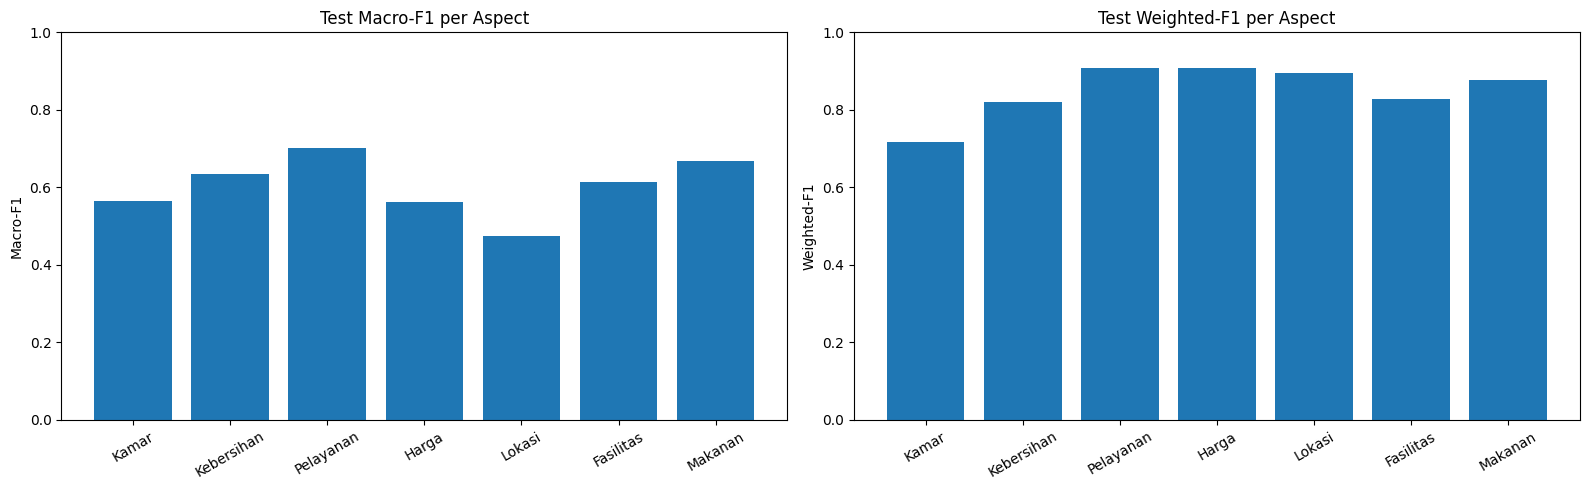

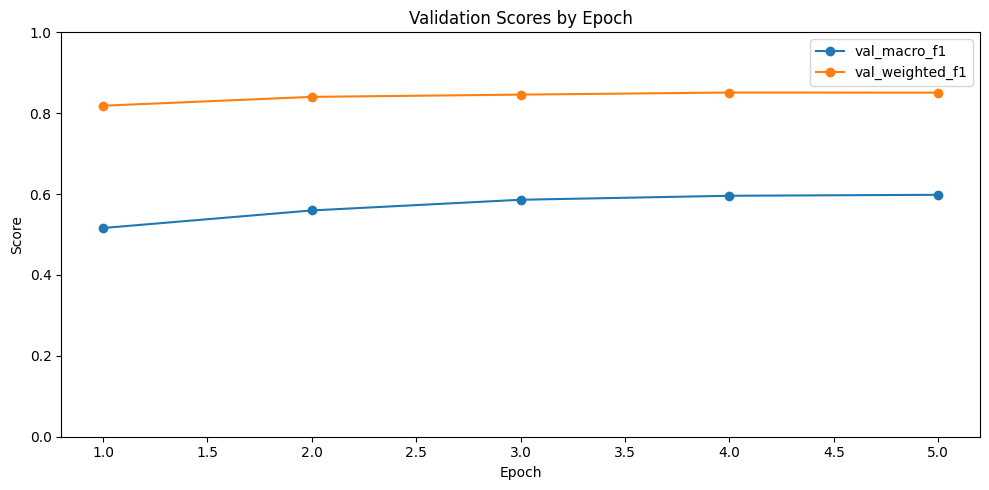

In [15]:
try:
    import matplotlib.pyplot as plt

    plot_df = final_metrics_df.loc[final_metrics_df["aspect"].ne("__overall_mean__")].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    test_plot = plot_df.loc[plot_df["split"].eq("test")]
    axes[0].bar(test_plot["aspect"], test_plot["macro_f1"])
    axes[0].set_title("Test Macro-F1 per Aspect")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("Macro-F1")

    axes[1].bar(test_plot["aspect"], test_plot["weighted_f1"])
    axes[1].set_title("Test Weighted-F1 per Aspect")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].set_ylabel("Weighted-F1")

    plt.tight_layout()
    plt.show()

    if len(history_df):
        plt.figure(figsize=(10, 5))
        plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
        plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o", label="val_weighted_f1")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Validation Scores by Epoch")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

except Exception as exc:
    print("Visualisasi dilewati:", exc)

### 16. Penyusunan Ringkasan Konfigurasi dan Hasil Pelatihan (JSON)


In [16]:
training_config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "encoder_source": getattr(model, "encoder_source", MODEL_NAME),
    "max_length": MAX_LENGTH,
    "epochs_configured": EPOCHS,
    "best_epoch": int(best_epoch),
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "dropout": DROPOUT,
    "max_grad_norm": MAX_GRAD_NORM,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_amp": amp_enabled,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "class_weight_power": CLASS_WEIGHT_POWER,
    "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
    "aspects": ASPECTS,
    "label_to_id": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "train_rows": int(len(train_dataset)),
    "val_rows": int(len(val_dataset)),
    "test_rows": int(len(test_dataset)),
    "best_val_macro_f1": float(best_val_macro_f1),
    "test_overall": test_overall,
}

with open(OUTPUT_DIR / "training_config_text_only_indobert.json", "w", encoding="utf-8") as f:
    json.dump(training_config, f, ensure_ascii=False, indent=2)

class_weight_used_table.to_csv(OUTPUT_DIR / "class_weights_used_text_only_indobert.csv", index=False, encoding="utf-8-sig")

methodology_notes = f"""# Methodology Notes - Notebook 07 Text-Only Baseline IndoBERT

## Tujuan

Notebook 07 melatih baseline text-only IndoBERT untuk 7 aspek MABSA hotel.

## Dasar Metodologi

1. BERT fine-tuning menambahkan task-specific classification layer di atas pretrained encoder.
2. IndoBERT/IndoNLU mendukung baseline bahasa Indonesia yang sesuai dengan domain review hotel Indonesia.
3. Multi-head classifier digunakan karena setiap review punya 7 target aspek.
4. Class weight dipakai dengan dampening untuk mengatasi imbalance tanpa membuat loss terlalu ekstrem.
5. Checkpoint terbaik dipilih berdasarkan validation macro-F1 karena dataset memiliki kelas `None` dominan.

## Konfigurasi Utama

- Model: {MODEL_NAME}
- Max length: {MAX_LENGTH}
- Batch size: {BATCH_SIZE}
- Epoch configured: {EPOCHS}
- Learning rate: {LEARNING_RATE}
- Weight decay: {WEIGHT_DECAY}
- Warmup ratio: {WARMUP_RATIO}
- Dropout: {DROPOUT}
- Class weight enabled: {USE_CLASS_WEIGHTS}
- Class weight power: {CLASS_WEIGHT_POWER}
- Class weight clip max: {CLASS_WEIGHT_CLIP_MAX}

## Hasil Ringkas

- Best epoch: {best_epoch}
- Best validation macro-F1: {best_val_macro_f1}
- Test overall macro-F1: {test_overall["macro_f1"]}
- Test overall weighted-F1: {test_overall["weighted_f1"]}

"""

with open(OUTPUT_DIR / "methodology_notes_notebook_07.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

print(json.dumps(training_config, ensure_ascii=False, indent=2))

{
  "seed": 42,
  "model_name": "indobenchmark/indobert-base-p1",
  "encoder_source": "indobenchmark/indobert-base-p1",
  "max_length": 256,
  "epochs_configured": 5,
  "best_epoch": 5,
  "batch_size": 16,
  "gradient_accumulation_steps": 1,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "dropout": 0.2,
  "max_grad_norm": 1.0,
  "early_stopping_patience": 2,
  "use_amp": true,
  "use_class_weights": true,
  "class_weight_power": 0.5,
  "class_weight_clip_max": 10.0,
  "aspects": [
    "Kamar",
    "Kebersihan",
    "Pelayanan",
    "Harga",
    "Lokasi",
    "Fasilitas",
    "Makanan"
  ],
  "label_to_id": {
    "None": 0,
    "Negatif": 1,
    "Netral": 2,
    "Positif": 3
  },
  "id_to_label": {
    "0": "None",
    "1": "Negatif",
    "2": "Netral",
    "3": "Positif"
  },
  "train_rows": 4796,
  "val_rows": 1029,
  "test_rows": 1029,
  "best_val_macro_f1": 0.598234,
  "test_overall": {
    "split": "test",
    "aspect": "__overall_mean__",
    "accuracy"

### 17. Verifikasi Keberhasilan Eksperimen (Critical Checks) dan Ekspor Output


In [17]:
checks = []
checks.append({"check": "history_has_rows", "value": int(len(history_df) > 0), "expected": 1})
checks.append({"check": "best_epoch_found", "value": int(best_epoch >= 1), "expected": 1})
checks.append({"check": "final_metrics_exists", "value": int((OUTPUT_DIR / "final_text_only_indobert_metrics.csv").exists()), "expected": 1})
checks.append({"check": "test_predictions_exists", "value": int((OUTPUT_DIR / "test_predictions_text_only_indobert.csv").exists()), "expected": 1})
checks.append({"check": "classification_report_exists", "value": int((OUTPUT_DIR / "classification_report_text_only_indobert.csv").exists()), "expected": 1})
checks.append({"check": "confusion_matrix_exists", "value": int((OUTPUT_DIR / "confusion_matrix_text_only_indobert_long.csv").exists()), "expected": 1})
checks.append({"check": "checkpoint_exists_or_disabled", "value": int((not SAVE_FULL_CHECKPOINT) or best_checkpoint_path.exists()), "expected": 1})
checks.append({"check": "test_overall_macro_f1_valid_range", "value": int(0.0 <= float(test_overall["macro_f1"]) <= 1.0), "expected": 1})

checks_df = pd.DataFrame(checks)
checks_df["status"] = checks_df.apply(lambda row: "OK" if row["value"] == row["expected"] else "NEEDS_REVIEW", axis=1)
checks_df.to_csv(OUTPUT_DIR / "notebook_07_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 07 selesai dengan catatan. Cek baris NEEDS_REVIEW sebelum lanjut Notebook 08.")
else:
    print("Notebook 07 selesai. Text-only IndoBERT baseline siap dibandingkan dengan image-only dan multimodal.")

,check,value,expected,status
0,history_has_rows,1,1,OK
1,best_epoch_found,1,1,OK
2,final_metrics_exists,1,1,OK
3,test_predictions_exists,1,1,OK
4,classification_report_exists,1,1,OK
5,confusion_matrix_exists,1,1,OK
6,checkpoint_exists_or_disabled,1,1,OK
7,test_overall_macro_f1_valid_range,1,1,OK


Notebook 07 selesai. Text-only IndoBERT baseline siap dibandingkan dengan image-only dan multimodal.


### 18. Kompresi Seluruh Output Baseline Model Teks ke Arsip ZIP


In [18]:
zip_base = OUTPUT_DIR.parent / "mabsa_text_only_indobert_baseline_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_text_only_indobert_baseline_outputs.zip

Files in output directory:
- best_text_only_indobert.pt
- class_weights_used_text_only_indobert.csv
- classification_report_text_only_indobert.csv
- confusion_matrix_text_only_indobert_long.csv
- final_text_only_indobert_metrics.csv
- methodology_notes_notebook_07.md
- notebook_07_checks.csv
- test_predictions_text_only_indobert.csv
- training_config_text_only_indobert.json
- training_history.csv
- val_metrics_epoch_1.csv
- val_metrics_epoch_2.csv
- val_metrics_epoch_3.csv
- val_metrics_epoch_4.csv
- val_metrics_epoch_5.csv
- val_predictions_text_only_indobert.csv
